In [1]:
import numpy as np
import matplotlib.pyplot as plt
import itertools
from scipy.special import factorial
from scipy.stats import binned_statistic
from matplotlib.ticker import ScalarFormatter

In [ ]:
class StructureFactor1D:
    def __init__(self, nLattice,q_value,prevS=None,prevSbinned = None, mass=26161e3, omegaNaught=10e-6, latticeConst=2*np.pi/2.28, couplingConst=28, energyThreshold = 1e-6):
        self.nLattice = nLattice # number of lattice
        # self.nPhononMax = nPhononMax
        self.mass = mass # Silicon: 26161e3 keV
        self.omegaNaught = omegaNaught # Silicon: 10e-6 keV, maximum energy 20 meV
        self.latticeConst = latticeConst # Silicon: 2*np.pi/2.28 keV^-1
        self.couplingConst = couplingConst # A, default: 28 for silicon
        self.volume = nLattice*8/(latticeConst**3) # propotional to nLattice
        self.prevS = prevS # (2,L) array containing L structure factors and its corresponding omega
        self.prevSbinned = prevSbinned # (2,L) array containing the sum of structure factors and its corresponding omega
        self.q_value = q_value
        self.omegaList = 2*self.omegaNaught*np.sin(np.pi*np.arange(1, self.nLattice)/self.nLattice) # num of energy levels: nLattice-1
        filter = np.argwhere(self.omegaList >= energyThreshold)
        self.omegaList = self.omegaList[filter].reshape(-1)
        self.nuList = np.arange(1, self.nLattice)[filter]

    def getDebyeWallerConst(self):
        '''
        Get W(q) appearing in the debye waller factor
        '''
        return self.q_value**2 / (4*self.mass*self.nLattice) * np.sum(1/self.omegaList)
        
    def partition(self, max_range, max_sum):
        max_range = np.asarray(max_range, dtype = int).ravel()        
        if(max_range.size == 1):
            return np.arange(min(max_range[0],max_sum) + 1, dtype = int).reshape(-1,1)
        P = self.partition(max_range[1:], max_sum)
        # S[i] is the largest summand we can place in front of P[i]            
        S = np.minimum(max_sum - P.sum(axis = 1), max_range[0])
        offset, sz = 0, S.size
        out = np.empty(shape = (sz + S.sum(), P.shape[1]+1), dtype = int)
        out[:sz,0] = 0
        out[:sz,1:] = P
        for i in range(1, max_range[0]+1):
            ind, = np.nonzero(S)
            offset, sz = offset + sz, ind.size
            out[offset:offset+sz, 0] = i
            out[offset:offset+sz, 1:] = P[ind]
            S[ind] -= 1
        return out
    
    def partitionwfilter(self, max_range, max_sum):
        arr = self.partition(max_range, max_sum)
        return arr[np.argwhere(np.sum(arr, axis=1) == max_sum)].reshape(-1, len(max_range))
    
    def getJVector(self, nPhonon):
        '''
        Get all posible sets of j_nu given the total number of phonons. 
        nPhonon: int
        '''
        jVector = self.partitionwfilter(nPhonon*np.ones(len(self.omegaList)), nPhonon)
        return jVector

    def get_allowed_omega(self, nPhonon):
        jVector = self.getJVector(nPhonon)
        allowed_omega = np.sum(np.multiply(self.omegaList, jVector),axis=1)
        return allowed_omega

    def get_diag_ini(self):
        DWfactor =  np.exp(- 2 * self.getDebyeWallerConst()) 
        s= 2 * np.pi / self.volume * self.nLattice * DWfactor * self.couplingConst**2 *  (self.q_value**2 /(2*self.mass*self.nLattice)) / self.omegaList
        return np.row_stack((s,self.omegaList))

    def get_diag_rec(self,nPhonon, prevS,):
        newS = (self.q_value**2 /(2*self.mass*self.nLattice))/nPhonon * prevS[0,:, np.newaxis] / self.omegaList 
        newOmega = prevS[1,:, np.newaxis] + self.omegaList 
        return np.row_stack((newS.T.reshape(-1,), newOmega.T.reshape(-1,)))

    def _bin_s_factor(self,sFactor, xlist, delta_omega):
        allowed_omegas = sFactor[1,:]
        s_diag = sFactor[0,:]
        result = binned_statistic(allowed_omegas, s_diag, statistic="sum",bins=len(xlist), range=(min(xlist), max(xlist)))
        ylist = result.statistic/delta_omega
        return xlist, ylist

    def get_diag(self, nPhonon):
        factor = 2 * np.pi / self.volume * np.exp(- 2 * self.getDebyeWallerConst()) 
        jVector = self.getJVector(nPhonon)
        prod_part = np.prod(1/(factorial(jVector)*(self.omegaList ** jVector)), axis=1)
        return factor * self.nLattice * self.couplingConst**2 * (self.q_value**2 /(2*self.mass*self.nLattice))**nPhonon * prod_part
    
    def get_binned_s_diag(self,nPhonon, xlist, delta_omega):
        allowed_omegas = self.get_allowed_omega(nPhonon)
        s_diag = self.get_diag(nPhonon)
        result = binned_statistic(allowed_omegas, s_diag, statistic="sum",bins=len(xlist), range=(min(xlist), max(xlist)))
        ylist = result.statistic/delta_omega
        return xlist, ylist
    

    # WIP
    def get_c_offdiag_init(self, l_diff): # l' minus l
        DWfactor =  np.exp(- 2 * self.getDebyeWallerConst()) 
        offdiag_factor = x
        return 2 * np.pi / self.volume * DWfactor * self.couplingConst**2 *  (self.q_value**2 /(2*self.mass*self.nLattice)) / self.omegaList

    def get_coherent_rec(self, nPhonon, prevS):

        return

   
    # def get_off_diag_sum_jVec_single_n_real_part(self, nPhonon, xi): 
    #     '''
    #     xi: integer, defined as l-l' 
    #     --------returns--------
    #     the summation of j_nu vectors
    #     '''
    #     # dont forget to multiply 2 when calculating the structure factor
    #     jVector = self.getJVector(nPhonon)
    #     # print("xi",xi)
    #     cos_part = np.cos(xi * ((self.q_list[np.newaxis, :] * self.latticeConst) 
    #                             - 2 * np.pi * np.einsum('i,ji->j',np.arange(1, self.nLattice), jVector)[:, np.newaxis] / self.nLattice)) 
    #     prod_part = np.prod(1/(factorial(jVector)*(self.omegaList ** jVector)), axis=1)
    #     return np.sum(prod_part[:, np.newaxis]*cos_part,axis=0)
    
    # # WIP
    # def get_off_diag_sum_jVec_single_n_real_part(self, nPhonon, xi): 
    #     '''
    #     xi: integer, defined as l-l' 
    #     --------returns--------
    #     the summation of j_nu 
    #     '''
    #     # dont forget to multiply 2 when calculating the structure factor
    #     jVector = self.getJVector(nPhonon)
    #     # print("xi",xi)
    #     cos_part = np.cos(xi * ((self.q_value * self.latticeConst)- 2 * np.pi * np.einsum('i,ji->j',np.arange(1, self.nLattice), jVector)/ self.nLattice)) 
    #     prod_part = np.prod(1/(factorial(jVector)*(self.omegaList ** jVector)), axis=1)
    #     return prod_part*cos_part
    
    # # WIP
    # def get_off_diag(self, nPhonon):
    #     2 * (self.nLattice-xi) * self


39


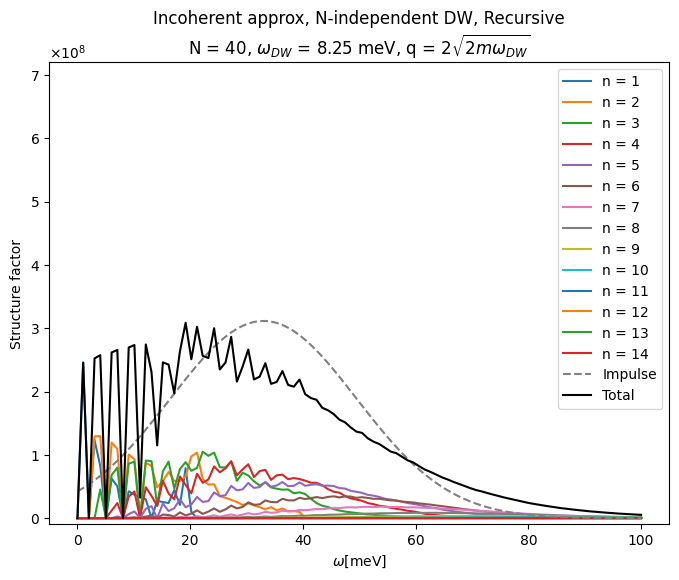

In [52]:
class StructureFactor1D_NIndepDW(StructureFactor1D):
    def getDebyeWallerConst(self):
        return self.q_value**2 / (4*self.mass*8.25e-6) # take W(q) = q^2/(4 m omega_DW) 

multplier = 2
q_value  = multplier*np.sqrt(2*26161e3*8.25e-6)
nLattice = 40
test = StructureFactor1D_NIndepDW(nLattice = nLattice,q_value=q_value, couplingConst=28,)
fmt = ['r-', 'g-', 'b-', 'y-', 'c-']
max_omega = 100*1e-6 # keV
xlist, delta_omega = np.linspace(0, max_omega,100, retstep=True) 
# impulse approx
deltasq = q_value**2 * 8.25e-6/(2*test.mass)
ia =  28**2 / (8/(test.latticeConst**3)) * np.sqrt(2*np.pi/deltasq) * np.exp(- (xlist-(q_value**2/(2*test.mass)))**2 / (2*deltasq))
sum = np.zeros(xlist.shape)
fig, ax = plt.subplots(figsize=(8,6))

prevS = test.get_diag_ini()
omegalist, s_diag = test._bin_s_factor(prevS,xlist, delta_omega)
sum = sum+s_diag
ax.plot(omegalist*1e6, s_diag,label=f'n = {1}')
print(len(prevS[1,:]))
for i in range(2,5,):
    # omegas = test.get_allowed_omega(i) # x axis: omega
    newS = test.get_diag_rec(i,prevS) # y axis: S, diag part
    omegalist, s_diag = test._bin_s_factor(newS,xlist, delta_omega)
    prevS = newS
    s_diag = np.nan_to_num(s_diag, nan=0.0)
    # fil = omegalist <= max_omega
    # omegalist, s_diag = omegalist[fil], s_diag[fil]
    sum = sum+s_diag
    ax.plot(omegalist*1e6, s_diag,label=f'n = {i}')
    formatter = ScalarFormatter(useMathText=True)
    formatter.set_powerlimits((8,8))
    ax.yaxis.set_major_formatter(formatter)
    # ax.ticklabel_format(style="sci",  axis="y", scilimits=(0,0))
_x_list, _delta_omega = np.linspace(0, max_omega,500, retstep=True) 
prevS = np.row_stack(test._bin_s_factor(newS,_x_list, _delta_omega))[::-1]
for i in range(5,15):
    newS = test.get_diag_rec(i,prevS)   
    omegalist, s_diag = test._bin_s_factor(newS,xlist, delta_omega)
    s_diag = _delta_omega*s_diag
    prevS = np.row_stack(test._bin_s_factor(newS,_x_list, _delta_omega))[::-1]
    prevS[0,:] = prevS[0,:] * _delta_omega
    s_diag = np.nan_to_num(s_diag, nan=0.0)
    # fil = omegalist <= max_omega
    # omegalist, s_diag = omegalist[fil], s_diag[fil]
    sum = sum+s_diag
    ax.plot(omegalist*1e6, s_diag,label=f'n = {i}')
    formatter = ScalarFormatter(useMathText=True)
    formatter.set_powerlimits((8,8))
    ax.yaxis.set_major_formatter(formatter)
ax.plot(xlist*1e6, ia, linestyle="--", color="gray", label='Impulse')
ax.plot(xlist*1e6,sum, label="Total",color="black")
txt1 = r"$\omega_{DW}$" #r"exp$(\frac{q^2}{4m\omega_{DW}})$"
txt2 = r"$\sqrt{2m\omega_{DW}}$" 
plt.ylim(-0.1e8, 7.2e8)
plt.title(f'Incoherent approx, N-independent DW, Recursive\nN = {nLattice}, {txt1} = 8.25 meV, q = {multplier}{txt2}')# , {txt} = {test.omegaNaught*1e6} meV
plt.ylabel('Structure factor')
plt.xlabel(r'$\omega$[meV]')
plt.legend()
plt.savefig(f"sfactorwrtomega_q{int(q_value)}_{nLattice}lattice_NindepDW_energyCut_recur", bbox_inches="tight")


In [38]:
def func():
    return np.array([1,2,3]), np.array([4,5,6])
np.row_stack(func())[::-1]

array([[4, 5, 6],
       [1, 2, 3]])

In [4]:
test = StructureFactor1D(nLattice = 5,q_value=55)
# test.get_off_diag_sum_jVec_single_n_real_part(2,np.array(  [1,2])).shape

In [5]:
# class StructureFactor1D_NIndepDW(StructureFactor1D):
#     def getDebyeWallerConst(self):
#         return self.q_value**2 / (4*self.mass*12e-6) # take W(q) = q^2/(4 pi m2omega0) 

In [6]:
# plt.hist(StructureFactor1D(nLattice = 6000,q_value=25).omegaList*1e6,bins=20)

In [7]:
for i in [10, 25, 30, 100, 200, 500,1000,10000,20000,30000,1e6]:
    omegas = StructureFactor1D(nLattice = i,q_value=25).omegaList
    # filter = np.argwhere(omegas >= 1e-6)
    # omegas = omegas[filter]
    totinvomg = np.mean(1/omegas)
    print("NLattice:", i)
    print('Sum of inverse omega:', totinvomg)

NLattice: 10
Sum of inverse omega: 85832.21995491028
NLattice: 25
Sum of inverse omega: 110887.54273022992
NLattice: 30
Sum of inverse omega: 116128.60234672674
NLattice: 100
Sum of inverse omega: 122422.14386289085
NLattice: 200
Sum of inverse omega: 118429.97327506139
NLattice: 500
Sum of inverse omega: 122966.03323374708
NLattice: 1000
Sum of inverse omega: 122033.95586969686
NLattice: 10000
Sum of inverse omega: 121211.68258470815
NLattice: 20000
Sum of inverse omega: 121257.05809408688
NLattice: 30000
Sum of inverse omega: 121272.19425879541
NLattice: 1000000.0
Sum of inverse omega: 121261.60929830722


In [8]:
1/110887.54273022992

9.018145549792061e-06

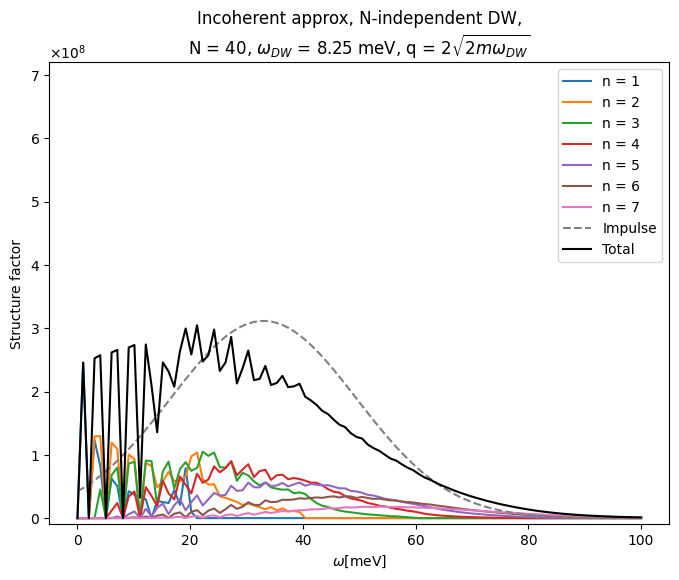

In [53]:
class StructureFactor1D_NIndepDW(StructureFactor1D):
    def getDebyeWallerConst(self):
        return self.q_value**2 / (4*self.mass*8.25e-6) # take W(q) = q^2/(4 m omega_DW) 

multplier = 2
q_value  = multplier*np.sqrt(2*26161e3*8.25e-6)
nLattice = 40
test = StructureFactor1D_NIndepDW(nLattice = nLattice,q_value=q_value, couplingConst=28,)
fmt = ['r-', 'g-', 'b-', 'y-', 'c-']
max_omega = 100*1e-6 # keV
xlist, delta_omega = np.linspace(0, max_omega, 100, retstep=True) 
# impulse approx
deltasq = q_value**2 * 8.25e-6/(2*test.mass)
ia =  28**2 / (8/(test.latticeConst**3)) * np.sqrt(2*np.pi/deltasq) * np.exp(- (xlist-(q_value**2/(2*test.mass)))**2 / (2*deltasq))
sum = np.zeros(xlist.shape)
# plot
fig, ax = plt.subplots(figsize=(8,6))
for i in range(1,8,):
    # omegas = test.get_allowed_omega(i) # x axis: omega
    omegalist, s_diag = test.get_binned_s_diag(i,xlist, delta_omega) # y axis: S, diag part
    # markerline, stemlines, baseline  = plt.stem(np.linspace(0,100,100), s_diag, linefmt=fmt[i-1],markerfmt=' ', basefmt="w",label=f'n = {i}')
    s_diag = np.nan_to_num(s_diag, nan=0.0)
    fil = omegalist <= max_omega
    omegalist, s_diag = omegalist[fil], s_diag[fil]
    sum = sum+s_diag
    ax.plot(omegalist*1e6, s_diag,label=f'n = {i}')
    formatter = ScalarFormatter(useMathText=True)
    formatter.set_powerlimits((8,8))
    ax.yaxis.set_major_formatter(formatter)
    # ax.ticklabel_format(style="sci",  axis="y", scilimits=(0,0))
ax.plot(xlist*1e6, ia, linestyle="--", color="gray", label='Impulse')
ax.plot(xlist*1e6,sum, label="Total",color="black")
txt1 = r"$\omega_{DW}$" #r"exp$(\frac{q^2}{4m\omega_{DW}})$"
txt2 = r"$\sqrt{2m\omega_{DW}}$"
plt.ylim(-0.1e8, 7.2e8)
plt.title(f'Incoherent approx, N-independent DW,\nN = {nLattice}, {txt1} = 8.25 meV, q = {multplier}{txt2}')# , {txt} = {test.omegaNaught*1e6} meV
plt.ylabel('Structure factor')
plt.xlabel(r'$\omega$[meV]')
plt.legend()
plt.savefig(f"sfactorwrtomega_q{int(q_value)}_{nLattice}lattice_NindepDW_energyCut", bbox_inches="tight")


In [13]:
arr1 = np.array([[1,2,3,4,5],[6,7,8,9,0]])
arr2 = np.array([11,22,33,44])
arr1[1,:,np.newaxis] +arr2
39*39*39

59319

In [10]:
40.3**2 /(2*test.mass)

3.104028897977905e-05

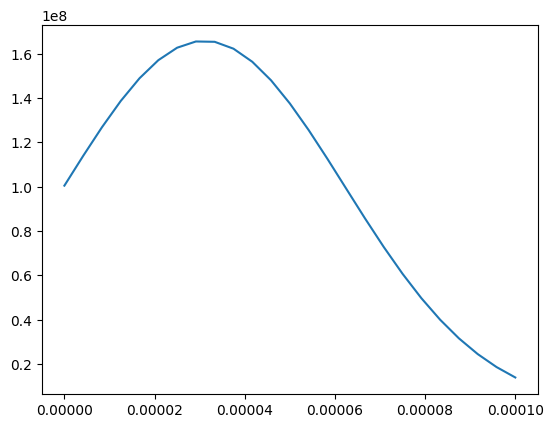

In [11]:
deltasq = 40.3**2 * 31e-6/(2*test.mass)
ia =  28**2 / (8/(test.latticeConst**3)) * np.sqrt(2*np.pi/deltasq) * np.exp( -(xlist-(40.3**2/(2*test.mass)))**2/(2*deltasq))
plt.plot(xlist, ia)


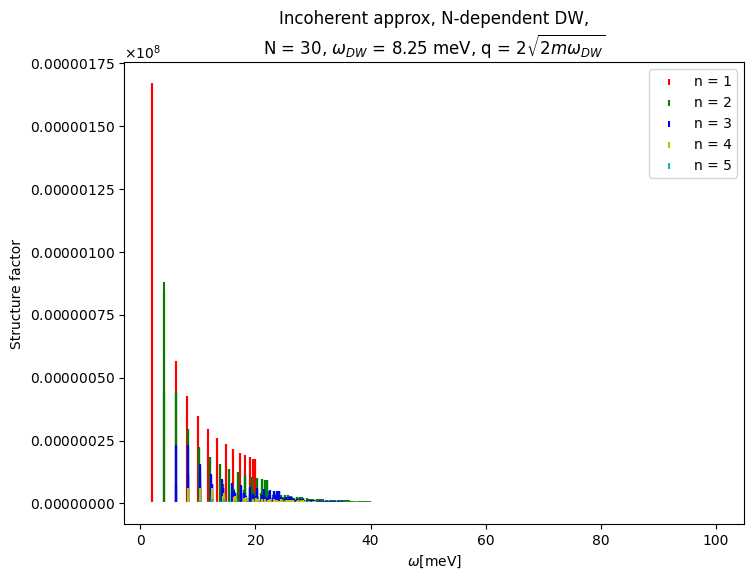

In [12]:
# class StructureFactor1D_NIndepDW(StructureFactor1D):
#     def getDebyeWallerConst(self):
#         return self.q_value**2 / (4*self.mass*8.25e-6) # take W(q) = q^2/(4 m omega_DW) 

multplier = 2
q_value  = multplier*np.sqrt(2*26161e3*8.25e-6)
nLattice = 30
test = StructureFactor1D(nLattice = nLattice,q_value=q_value, couplingConst=28,)
fmt = ['r-', 'g-', 'b-', 'y-', 'c-']
max_omega = 100*1e-6 # keV
xlist, delta_omega = np.linspace(0, max_omega, 100, retstep=True)
deltasq = q_value**2 * 8.25e-6/(2*test.mass)
# ia =  28**2 / (8/(test.latticeConst**3)) * np.sqrt(2*np.pi/deltasq) * np.exp(- (xlist-(q_value**2/(2*test.mass)))**2 / (2*deltasq))
sum = np.zeros(xlist.shape)
fig, ax = plt.subplots(figsize=(8,6))
for i in range(1,6,):
    omegas = test.get_allowed_omega(i) # x axis: omega
    s_diag = test.get_diag(i) # y axis: S, diag part
    # markerline, stemlines, baseline  = 
    plt.stem(omegas*1e6, s_diag, linefmt=fmt[i-1],markerfmt=' ', basefmt="w",label=f'n = {i}')
    # s_diag = np.nan_to_num(s_diag, nan=0.0)
    # fil = omegalist <= max_omega
    # omegalist, s_diag = omegalist[fil], s_diag[fil]
    # sum = sum+s_diag
    # ax.plot(omegas*1e6, s_diag,label=f'n = {i}')
    formatter = ScalarFormatter(useMathText=True)
    formatter.set_powerlimits((8,8))
    ax.yaxis.set_major_formatter(formatter)
    # ax.ticklabel_format(style="sci",  axis="y", scilimits=(0,0))
# ax.plot(xlist*1e6, ia, linestyle="--", color="gray", label='Impulse')
# ax.plot(xlist*1e6,sum, label="Total",color="black")
txt1 = r"$\omega_{DW}$" #r"exp$(\frac{q^2}{4m\omega_{DW}})$"
txt2 = r"$\sqrt{2m\omega_{DW}}$"
# plt.ylim(-0.1e8, 7.2e8)
plt.title(f"Incoherent approx, N-dependent DW,\nN = {nLattice}, {txt1} = 8.25 meV, q = {multplier}{txt2}")# , {txt} = {test.omegaNaught*1e6} meV
plt.ylabel('Structure factor')
plt.xlabel(r'$\omega$[meV]')
plt.legend()
# plt.savefig(f"sfactorwrtomega_q{int(q_value)}_{nLattice}lattice_energyCut", bbox_inches="tight")

In [13]:
delta_omega

1.01010101010101e-06

In [14]:
i=5
omegas = test.get_allowed_omega(i) # x axis: omega
s_diag = test.get_diag(i) 
xlist, delta_omega= np.linspace(0, max(omegas), num=100, retstep=True)
result = binned_statistic(omegas, s_diag, statistic="sum",bins=len(xlist), range=(min(xlist), max(xlist)))
ylist = result.statistic/delta_omega

print("allowed omegas:\n", np.sort(omegas)[4010:4050])
print("corresponding structure factors:\n",s_diag[np.argsort(omegas)][4010:4050])

allowed omegas:
 [3.46536465e-05 3.46536465e-05 3.46765512e-05 3.46765512e-05
 3.46765512e-05 3.46765512e-05 3.46765512e-05 3.46765512e-05
 3.46765512e-05 3.46765512e-05 3.46765512e-05 3.46765512e-05
 3.46765512e-05 3.46765512e-05 3.46765512e-05 3.46765512e-05
 3.46765512e-05 3.46765512e-05 3.46765512e-05 3.46765512e-05
 3.46765512e-05 3.46765512e-05 3.46765512e-05 3.46765512e-05
 3.46765512e-05 3.46765512e-05 3.47213595e-05 3.47213595e-05
 3.47213595e-05 3.47213595e-05 3.47213595e-05 3.47213595e-05
 3.47213595e-05 3.47213595e-05 3.47213595e-05 3.47213595e-05
 3.47221096e-05 3.47221096e-05 3.47221096e-05 3.47221096e-05]
corresponding structure factors:
 [0.01976754 0.03953507 0.07183847 0.14367694 0.07183847 0.07183847
 0.07183847 0.14367694 0.14367694 0.07183847 0.14367694 0.14367694
 0.07183847 0.07183847 0.14367694 0.07183847 0.14367694 0.07183847
 0.07183847 0.07183847 0.14367694 0.07183847 0.07183847 0.07183847
 0.07183847 0.07183847 0.00145881 0.00875286 0.00145881 0.00583524
 0.

In [15]:
result.bin_edges

array([0.0e+00, 1.0e-06, 2.0e-06, 3.0e-06, 4.0e-06, 5.0e-06, 6.0e-06,
       7.0e-06, 8.0e-06, 9.0e-06, 1.0e-05, 1.1e-05, 1.2e-05, 1.3e-05,
       1.4e-05, 1.5e-05, 1.6e-05, 1.7e-05, 1.8e-05, 1.9e-05, 2.0e-05,
       2.1e-05, 2.2e-05, 2.3e-05, 2.4e-05, 2.5e-05, 2.6e-05, 2.7e-05,
       2.8e-05, 2.9e-05, 3.0e-05, 3.1e-05, 3.2e-05, 3.3e-05, 3.4e-05,
       3.5e-05, 3.6e-05, 3.7e-05, 3.8e-05, 3.9e-05, 4.0e-05, 4.1e-05,
       4.2e-05, 4.3e-05, 4.4e-05, 4.5e-05, 4.6e-05, 4.7e-05, 4.8e-05,
       4.9e-05, 5.0e-05, 5.1e-05, 5.2e-05, 5.3e-05, 5.4e-05, 5.5e-05,
       5.6e-05, 5.7e-05, 5.8e-05, 5.9e-05, 6.0e-05, 6.1e-05, 6.2e-05,
       6.3e-05, 6.4e-05, 6.5e-05, 6.6e-05, 6.7e-05, 6.8e-05, 6.9e-05,
       7.0e-05, 7.1e-05, 7.2e-05, 7.3e-05, 7.4e-05, 7.5e-05, 7.6e-05,
       7.7e-05, 7.8e-05, 7.9e-05, 8.0e-05, 8.1e-05, 8.2e-05, 8.3e-05,
       8.4e-05, 8.5e-05, 8.6e-05, 8.7e-05, 8.8e-05, 8.9e-05, 9.0e-05,
       9.1e-05, 9.2e-05, 9.3e-05, 9.4e-05, 9.5e-05, 9.6e-05, 9.7e-05,
       9.8e-05, 9.9e

(-0.1, 0.8)

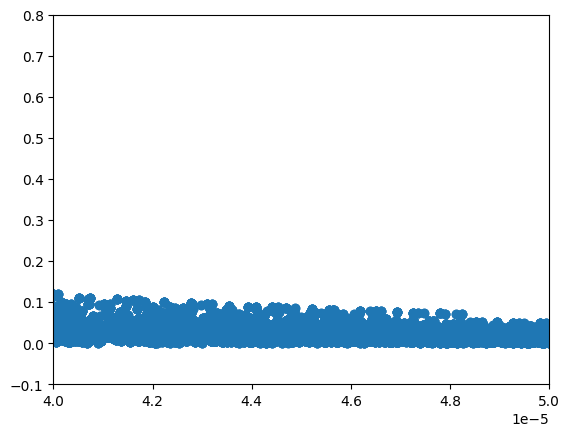

In [16]:
plt.scatter(omegas, s_diag)
plt.xlim(4e-5, 5e-5)
plt.ylim(-0.1, .8)

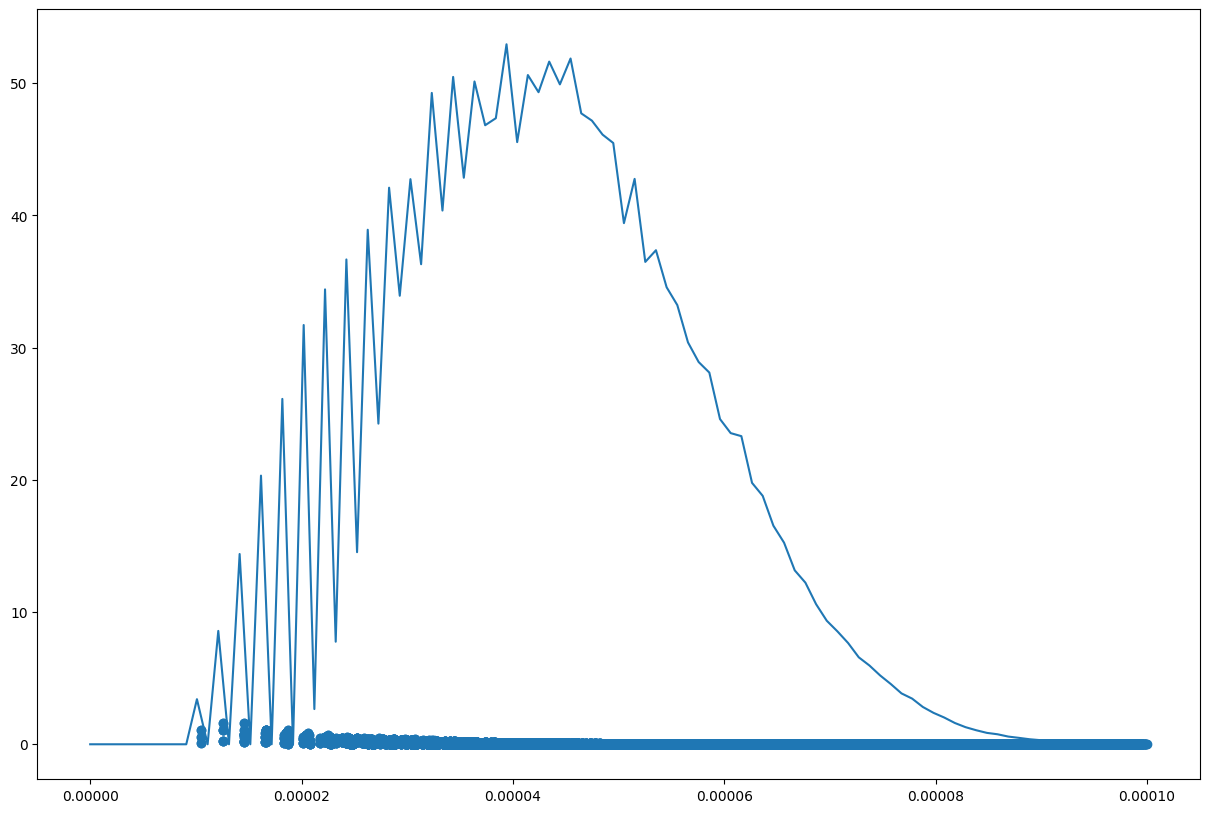

In [17]:
i=5
omegas = test.get_allowed_omega(i) # x axis: omega
s_diag = test.get_diag(i) 
xlist, delta_omega= np.linspace(0, max(omegas), num=100, retstep=True)
result = binned_statistic(omegas, s_diag, statistic="sum",bins=len(xlist), range=(min(xlist), max(xlist)))
ylist = result.statistic/delta_omega

plt.figure(figsize=(15,10))
plt.scatter(omegas, s_diag)
plt.plot(xlist, result.statistic)

In [18]:
omegas = test.get_allowed_omega(i) # x axis: omega
s_diag = test.get_diag(i) 
xlist, delta_omega= np.linspace(0, max(omegas), num=100, retstep=True)
result = binned_statistic(omegas, s_diag, statistic="sum",bins=len(xlist), range=(min(xlist), max(xlist)))
ylist = result.statistic/delta_omega

indexes = omegas.argsort()
sorted_omegas, sorted_s_diag = omegas[indexes], s_diag[indexes]

BSresult_num = binned_statistic(omegas,omegas , statistic='count',bins=len(xlist), range=(min(xlist), max(xlist)))
omegas_count = BSresult_num.statistic
binedges = BSresult_num.bin_edges


find_nearest_idx(sorted_omegas,binedges[:100]), len(s_diag), len(omegas)

NameError: name 'find_nearest_idx' is not defined

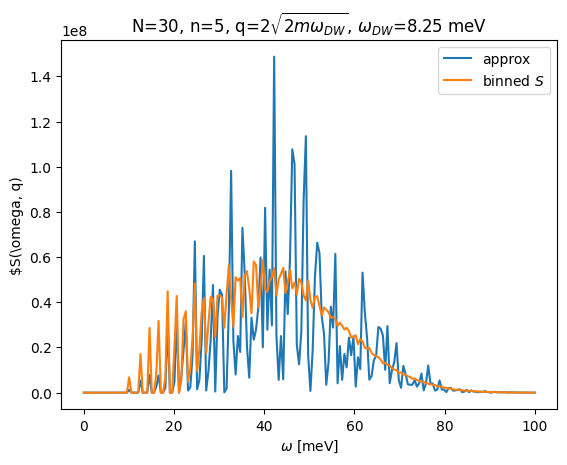

In [ ]:
def find_nearest_idx(array,value):
    idx = np.searchsorted(array, value, side="left")
    idx = idx - (np.abs(value - array[idx-1]) < np.abs(value - array[idx]))
    return idx

omegas = test.get_allowed_omega(i) # x axis: omega
s_diag = test.get_diag(i) 
xlist, delta_omega= np.linspace(0, max(omegas), num=200, retstep=True)
result = binned_statistic(omegas, s_diag, statistic="sum",bins=len(xlist), range=(min(xlist), max(xlist)))
ylist = result.statistic/delta_omega

indexes = omegas.argsort()
sorted_omegas, sorted_s_diag = omegas[indexes], s_diag[indexes]

BSresult_num = binned_statistic(omegas,omegas , statistic='count',bins=len(xlist), range=(min(xlist), max(xlist)))
omegas_count = BSresult_num.statistic
binedges = BSresult_num.bin_edges


s_selected = sorted_s_diag[find_nearest_idx(sorted_omegas,binedges[:len(binedges)-1])]
s_approx = omegas_count * s_selected/delta_omega
plt.plot(xlist*1e6, s_approx, label='approx')
plt.plot(xlist*1e6, ylist, label="binned $S$")
plt.xlabel(r"$\omega$ [meV]")
plt.ylabel('$S(\omega, q)')
txt2 = r""
plt.title(r'N=30, n=5, q=2$\sqrt{2m\omega_{DW}}$, $\omega_{DW}$=8.25 meV')
plt.legend()
plt.savefig("sfactor_approximated", bbox_inches="tight")

In [ ]:
# class StructureFactor1D_NIndepDW(StructureFactor1D):
#     def getDebyeWallerConst(self):
#         return self.q_value**2 / (4*self.mass*8.25e-6) # take W(q) = q^2/(4 m omega_DW) 

multplier = 2
q_value  = multplier*np.sqrt(2*26161e3*8.25e-6)
nLattice = 30
test = StructureFactor1D(nLattice = nLattice,q_value=q_value, couplingConst=28,)
fmt = ['r-', 'g-', 'b-', 'y-', 'c-']
max_omega = 100*1e-6 # keV
xlist, delta_omega = np.linspace(0, max_omega, 100, retstep=True)
deltasq = q_value**2 * 8.25e-6/(2*test.mass)
ia =  28**2 / (8/(test.latticeConst**3)) * np.sqrt(2*np.pi/deltasq) * np.exp(- (xlist-(q_value**2/(2*test.mass)))**2 / (2*deltasq))
sum = np.zeros(xlist.shape)
fig, ax = plt.subplots(figsize=(8,6))
for i in range(1,8,):
    # omegas = test.get_allowed_omega(i) # x axis: omega
    omegalist, s_diag = test.get_binned_s_diag(i,xlist, delta_omega) # y axis: S, diag part
    # markerline, stemlines, baseline  = plt.stem(np.linspace(0,100,100), s_diag, linefmt=fmt[i-1],markerfmt=' ', basefmt="w",label=f'n = {i}')
    s_diag = np.nan_to_num(s_diag, nan=0.0)
    fil = omegalist <= max_omega
    omegalist, s_diag = omegalist[fil], s_diag[fil]
    sum = sum+s_diag
    ax.plot(omegalist*1e6, s_diag,label=f'n = {i}')
    formatter = ScalarFormatter(useMathText=True)
    formatter.set_powerlimits((8,8))
    ax.yaxis.set_major_formatter(formatter)
    # ax.ticklabel_format(style="sci",  axis="y", scilimits=(0,0))
ax.plot(xlist*1e6, ia, linestyle="--", color="gray", label='Impulse')
ax.plot(xlist*1e6,sum, label="Total",color="black")
txt1 = r"$\omega_{DW}$" #r"exp$(\frac{q^2}{4m\omega_{DW}})$"
txt2 = r"$\sqrt{2m\omega_{DW}}$"
plt.ylim(-0.1e8, 7.2e8)
plt.title(f"Incoherent approx, N-dependent DW,\nN = {nLattice}, {txt1} = 8.25 meV, q = {multplier}{txt2}")# , {txt} = {test.omegaNaught*1e6} meV
plt.ylabel('Structure factor')
plt.xlabel(r'$\omega$[meV]')
plt.legend()
plt.savefig(f"sfactorwrtomega_q{int(q_value)}_{nLattice}lattice_energyCut", bbox_inches="tight")

: 

In [ ]:
multplier = 2
q_value  = multplier*np.sqrt(2*26161e3*8.25e-6)
nLattice = 40
test = StructureFactor1D(nLattice = nLattice,q_value=q_value, couplingConst=28,)
omglst = test.get_allowed_omega(1)
sfactor = test.get_diag(1)
min(omglst), test.omegaList

(1.569181914556899e-06,
 array([1.56918191e-06, 3.12868930e-06, 4.66890728e-06, 6.18033989e-06,
        7.65366865e-06, 9.07980999e-06, 1.04499713e-05, 1.17557050e-05,
        1.29889610e-05, 1.41421356e-05, 1.52081193e-05, 1.61803399e-05,
        1.70528033e-05, 1.78201305e-05, 1.84775907e-05, 1.90211303e-05,
        1.94473984e-05, 1.97537668e-05, 1.99383467e-05, 2.00000000e-05,
        1.99383467e-05, 1.97537668e-05, 1.94473984e-05, 1.90211303e-05,
        1.84775907e-05, 1.78201305e-05, 1.70528033e-05, 1.61803399e-05,
        1.52081193e-05, 1.41421356e-05, 1.29889610e-05, 1.17557050e-05,
        1.04499713e-05, 9.07980999e-06, 7.65366865e-06, 6.18033989e-06,
        4.66890728e-06, 3.12868930e-06, 1.56918191e-06]))

In [ ]:
sfactor

array([123.25593419,  61.818533  ,  41.42532103,  31.2945544 ,
        25.27036271,  21.30121477,  18.50827886,  16.45252089,
        14.8904122 ,  13.67622175,  12.71761346,  11.95345612,
        11.34188787,  10.85351103,  10.46732696,  10.16821711,
         9.94533967,   9.79109375,   9.7004524 ,   9.67054914,
         9.7004524 ,   9.79109375,   9.94533967,  10.16821711,
        10.46732696,  10.85351103,  11.34188787,  11.95345612,
        12.71761346,  13.67622175,  14.8904122 ,  16.45252089,
        18.50827886,  21.30121477,  25.27036271,  31.2945544 ,
        41.42532103,  61.818533  , 123.25593419])

In [ ]:
r = binned_statistic(omglst, sfactor, statistic="sum",bins=100,range=(min(xlist), max(xlist)))
r.statistic

array([  0.        , 246.51186838,   0.        , 123.637066  ,
        82.85064205,   0.        ,  62.58910879,  50.54072542,
         0.        ,  42.60242954,  37.01655772,  32.90504177,
        29.78082439,   0.        ,  27.3524435 ,  25.43522691,
        23.90691223,  44.39079781,  20.93465392,  79.21020584,
         9.67054914,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.  

In [ ]:
x,y = test.get_binned_s_diag(1,xlist, delta_omega)
y

array([0.00000000e+00, 2.44046750e+08, 0.00000000e+00, 1.22400695e+08,
       8.20221356e+07, 0.00000000e+00, 6.19632177e+07, 5.00353182e+07,
       0.00000000e+00, 4.21764052e+07, 3.66463921e+07, 3.25759914e+07,
       2.94830161e+07, 0.00000000e+00, 2.70789191e+07, 2.51808746e+07,
       2.36678431e+07, 4.39468898e+07, 2.07253074e+07, 7.84181038e+07,
       9.57384365e+06, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
      

In [ ]:
q_value  =  2*np.sqrt(2*26161e3*8.25e-6)
test = StructureFactor1D(nLattice = 25,q_value=q_value, couplingConst=28,)
fmt = ['r-', 'g-', 'b-', 'y-', 'c-']
max_omega = 100*1e-6 # keV
xlist, delta_omega = np.linspace(0, max_omega, int(max_omega*1e6), retstep=True)
ip =  28**2*np.sqrt(2*np.pi/(q_value**2 * avgomg / (2*test.mass)))*np.exp(-(xlist-(q_value**2/(2*test.mass)))**2/(q_value**2 * avgomg / (test.mass)))
sum = np.zeros(xlist.shape)
fig, ax = plt.subplots(figsize=(8,6))
for i in range(1,8,):
    # omegas = test.get_allowed_omega(i) # x axis: omega
    omegalist, s_diag = test.get_binned_s_diag(i,xlist, delta_omega) # y axis: S, diag part
    # markerline, stemlines, baseline  = plt.stem(np.linspace(0,100,100), s_diag, linefmt=fmt[i-1],markerfmt=' ', basefmt="w",label=f'n = {i}')
    s_diag = np.nan_to_num(s_diag, nan=0.0)
    fil = omegalist <= max_omega
    omegalist, s_diag = omegalist[fil], s_diag[fil]
    sum = sum+s_diag
    ax.plot(omegalist*1e6, s_diag,label=f'n = {i}')
    formatter = ScalarFormatter(useMathText=True)
    formatter.set_powerlimits((8,8))
    ax.yaxis.set_major_formatter(formatter)
    # ax.ticklabel_format(style="sci",  axis="y", scilimits=(0,0))
# ax.plot(xlist*1e6, ip, linestyle="--", color="gray")
# ax.plot(xlist*1e6,sum, label="Total",color="black")
txt = r"$\omega_0$"
plt.title(f"N = 25, q = {q_value:.1f} keV, bin size = {delta_omega*1e6:.1f} meV") # , {txt} = {test.omegaNaught*1e6} meV
plt.ylabel('Structure factor')
plt.xlabel(r'$\omega$[meV]')
plt.legend()
# plt.savefig(f"sfactorwrtomega_q{int(q_value)}", bbox_inches="tight")

NameError: name 'avgomg' is not defined

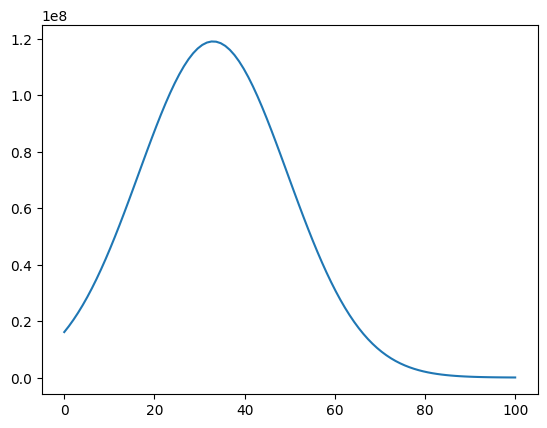

In [ ]:
plt.plot(xlist*1e6, ip*28**2)

In [ ]:
avgomg, test.mass

(np.float64(7.694208842938133e-05), 26161000.0)

In [ ]:
np.sqrt(q_value**2*avgomg*1e-6/(2*test.mass))

np.float64(6.669641738808933e-08)

In [ ]:
testS = test.get_diag(1)
omgs = test.get_allowed_omega(1)
binned_statistic(omgs, testS, statistic="mean",bins=20).statistic

array([25.25029806,         nan, 12.72549335,         nan,         nan,
        8.59682268,         nan,         nan,  6.56912791,         nan,
        5.38411179,         nan,  4.62305877,         nan,  4.10726426,
               nan,  3.74819002,  3.49757613,  3.32756408,  3.19636327])

In [ ]:
np.arange(10)+10

array([10, 11, 12, 13, 14, 15, 16, 17, 18, 19])